In [2]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
conn = duckdb.connect()

def q(query: str):
    return conn.execute(query).df()

In [15]:
q('''
select * 
from '../traces/fb23/reag.parquet'
limit 5
  ''')

,timestamp,cacheKey,OpType,objectSize,responseSize,responseHeaderSize,rangeStart,rangeEnd,TTL,SamplingRate,cache_hit,item_value,RequestHandler,cdn_content_type_id,vip_type
0,1678863509425,0067813353300000000000000000000000000000000000...,1,-1,246307,547,-1,-1,1209600,0.0001,0,1,1000,9,2000
1,1678863511382,0067813353400000000000000000000000000000000000...,1,-1,2736128,0,-1,-1,1209600,0.0001,0,1,1000,2,2000
2,1678863569821,0067813353500000000000000000000000000000000000...,1,25568,26063,450,-1,-1,1209600,0.0001,0,1,1000,15,2000
3,1678863576365,0067813353600000000000000000000000000000000000...,1,20914,23493,2561,-1,-1,1209600,0.0001,0,0,1001,6,2001
4,1678863577913,0067813353700000000000000000000000000000000000...,1,10243,11691,1448,-1,-1,900,0.0001,0,1,1002,28,2002


In [13]:
q('''
select count(*) 
from '../traces/fb23/reag.parquet'
  ''')

,count_star()
0,50114842


In [29]:
q('''
select count(*) 
from '../traces/wm/t-all.parquet'
  ''')

,count_star()
0,197819321


In [25]:
q('''
with stats as (
    select cacheKey, count(*) as access_count
    from '../traces/fb23/reag.parquet'
    group by cacheKey
)
select
    sum(case when access_count = 1 then 1 else 0 end) / count(*) as a1,
    sum(case when access_count = 2 then 1 else 0 end) / count(*) as a2,
    sum(case when access_count = 3 then 1 else 0 end) / count(*) as a3,
    sum(case when access_count = 4 then 1 else 0 end) / count(*) as a4,
    sum(case when access_count = 5 then 1 else 0 end) / count(*) as a5
from stats
''')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,a1,a2,a3,a4,a5
0,0.650057,0.208726,0.053713,0.026738,0.013599


In [27]:
q('''
with stats as (
    select key, count(*) as access_count
    from '../traces/wm/t-all.parquet'
    group by key
)
select
    sum(case when access_count = 1 then 1 else 0 end) / count(*) as a1,
    sum(case when access_count = 2 then 1 else 0 end) / count(*) as a2,
    sum(case when access_count = 3 then 1 else 0 end) / count(*) as a3,
    sum(case when access_count = 4 then 1 else 0 end) / count(*) as a4,
    sum(case when access_count = 5 then 1 else 0 end) / count(*) as a5
from stats
''')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,a1,a2,a3,a4,a5
0,0.558991,0.138926,0.066806,0.040476,0.027484


In [34]:
reag_access_counts = q('''
select count(cacheKey) as cnt, count(cacheKey) / 50114842 as frac
from '../traces/fb23/reag.parquet'
group by cacheKey
order by cnt desc
limit 1000
  ''')
reag_access_counts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cnt,frac
0,11125252,0.221995
1,202798,0.004047
2,111075,0.002216
3,98938,0.001974
4,89733,0.001791
...,...,...
995,1305,0.000026
996,1305,0.000026
997,1300,0.000026
998,1299,0.000026


In [35]:
wm_access_counts = q('''
select count(key) as cnt, count(key) / 197819321 as frac
from '../traces/wm/t-all.parquet'
group by key
order by cnt desc
limit 1000
  ''')
wm_access_counts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cnt,frac
0,946048,0.004782
1,765288,0.003869
2,275306,0.001392
3,209517,0.001059
4,120681,0.000610
...,...,...
995,7074,0.000036
996,7064,0.000036
997,7063,0.000036
998,7057,0.000036


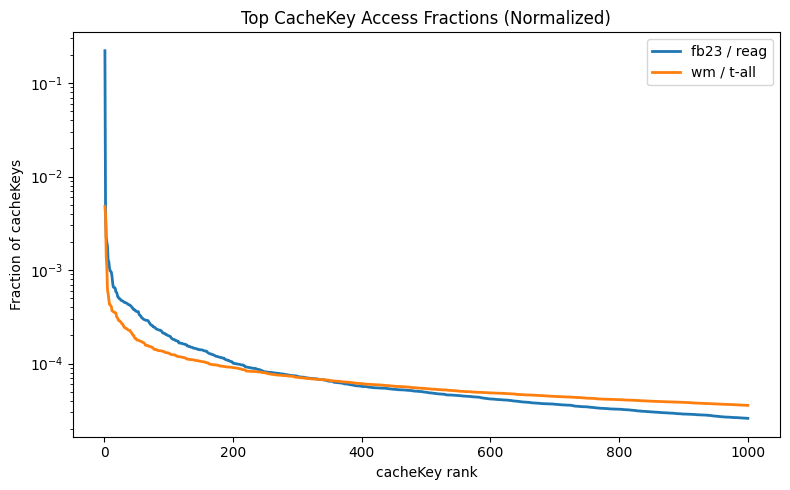

In [36]:
ranks_reag = np.arange(1, len(reag_access_counts) + 1)
ranks_wm = np.arange(1, len(wm_access_counts) + 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ranks_reag, reag_access_counts['frac'], label='fb23 / reag', linewidth=2)
ax.plot(ranks_wm, wm_access_counts['frac'], label='wm / t-all', linewidth=2)
ax.set_xlabel('cacheKey rank')
ax.set_ylabel('Fraction of cacheKeys')
ax.set_title('Top CacheKey Access Fractions (Normalized)')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

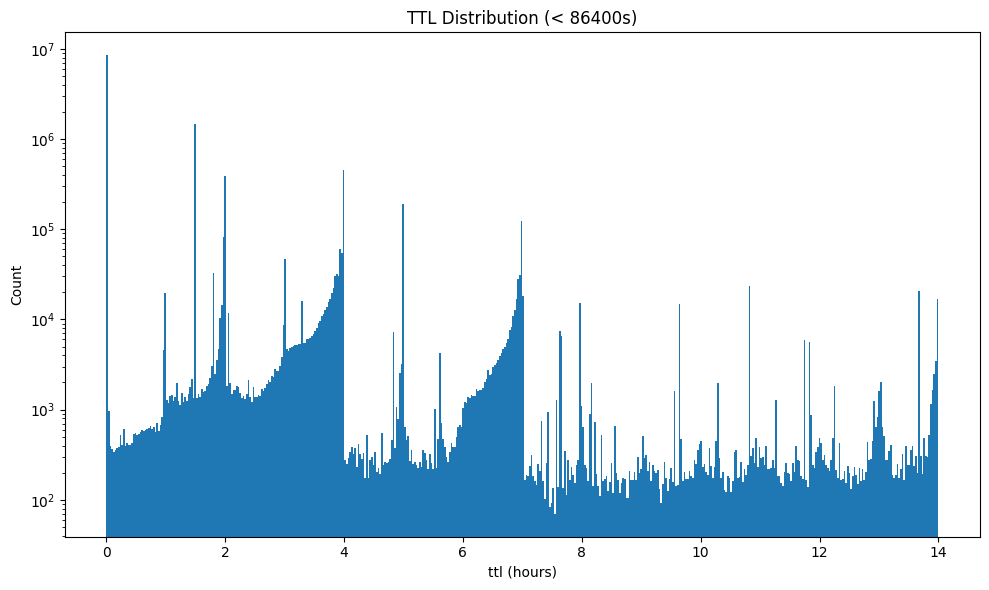

In [ ]:
df = q('''
select ttl / 24 / 3600 as ttl, count(*) as cnt
from '../traces/fb23/reag.parquet'
group by ttl
having ttl < 14*86400
order by ttl asc
  ''')

plt.figure(figsize=(10, 6))
plt.hist(
    df['ttl'],
    weights=df['cnt'],
    bins=500,
    log=True,
 )
plt.xlabel('ttl (hours)')
plt.ylabel('Count')
plt.title('TTL Distribution')
plt.tight_layout()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

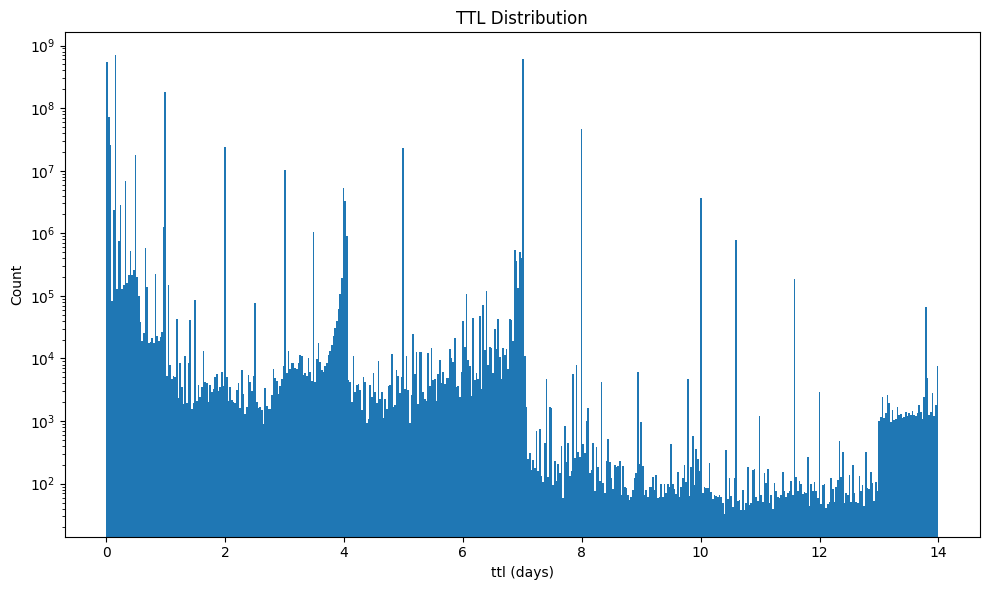

In [43]:
df = q('''
select expiry_time / 24 / 3600 as ttl, count(*) as cnt
from '../traces/cf/parquet/**/*.parquet'
group by ttl
having ttl < 14
order by ttl asc
  ''')

plt.figure(figsize=(10, 6))
plt.hist(
    df['ttl'],
    weights=df['cnt'],
    bins=500,
    log=True,
 )
plt.xlabel('ttl (days)')
plt.ylabel('Count')
plt.title('TTL Distribution')
plt.tight_layout()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

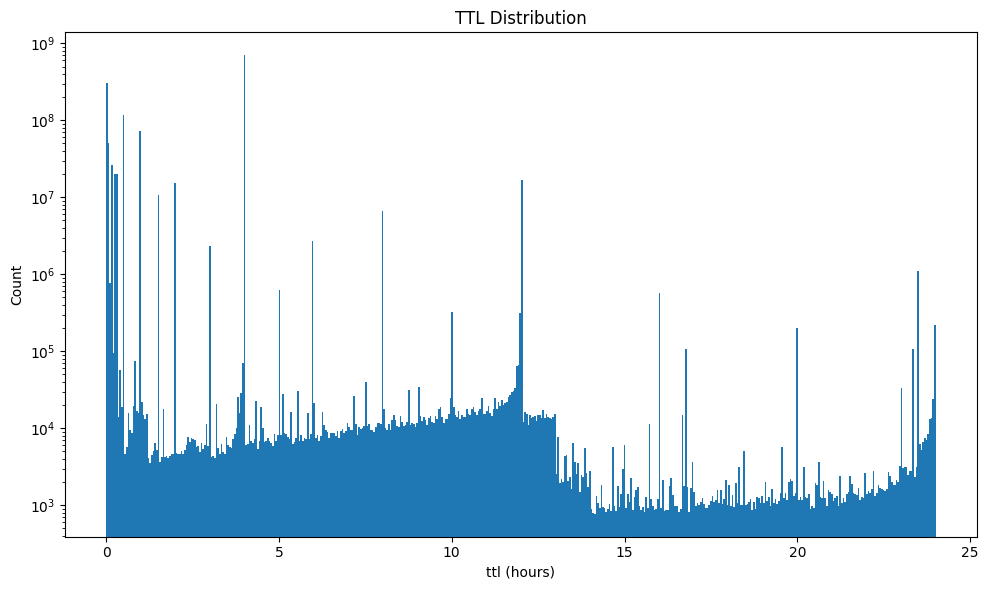

In [46]:
df = q('''
select expiry_time / 3600 as ttl, count(*) as cnt
from '../traces/cf/parquet/**/*.parquet'
group by ttl
having ttl < 24
order by ttl asc
  ''')

plt.figure(figsize=(10, 6))
plt.hist(
    df['ttl'],
    weights=df['cnt'],
    bins=500,
    log=True,
 )
plt.xlabel('ttl (hours)')
plt.ylabel('Count')
plt.title('TTL Distribution')
plt.tight_layout()